# Credit Card Fraud Detection

This notebook trains a machine learning model on real credit card transaction data to detect fraudulent activity. It covers data exploration, class imbalance handling, model training, and evaluation using precision, recall, and F1 score.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

## 2. Load Data

In [3]:
df = pd.read_csv('creditcard.csv')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [13]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [22]:
fraud_percentage = df['Class'].mean() * 100
print(f"{fraud_percentage:.4f}%")

0.1727%


## 3. Exploratory Data Analysis

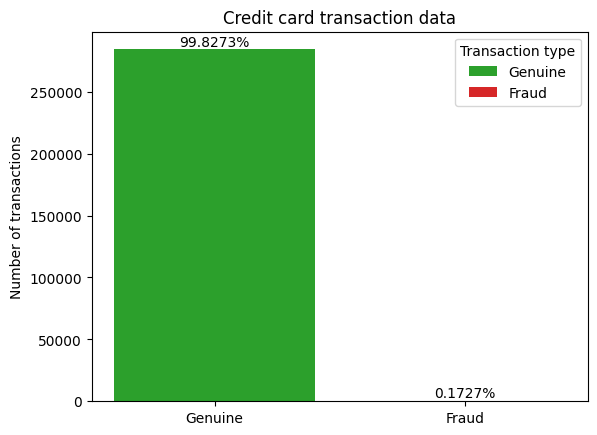

In [84]:
fig, ax = plt.subplots()

df_counts = df['Class'].value_counts()
bar1 = df_counts[0]
bar2 = df_counts[1]

fraud_percentage = df['Class'].mean() * 100
fraud_percentage_str = f"{fraud_percentage:.4f}%"
genuine_percentage_str = f"{100 - fraud_percentage:.4f}%"
percentages = [genuine_percentage_str, fraud_percentage_str]

labels = ['Genuine', 'Fraud']
counts = [bar1, bar2]

bar_labels = ['Genuine', 'Fraud']
bar_colors = ['tab:green', 'tab:red']

bar_container = ax.bar(labels, counts, label=bar_labels, color=bar_colors)

ax.set_ylabel('Number of transactions')
ax.set_title('Credit card transaction data')
ax.legend(title='Transaction type')
ax.bar_label(bar_container, percentages)

plt.show()

The dataset is heavily imbalanced. Only 0.17% of transactions are fraudulent. 
This means standard accuracy metrics are misleading and require special handling during model training.